In [45]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [46]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [47]:
NUM_CLASSES = 13

# Dataset reading

In [48]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [49]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [51]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [52]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_4 (Dropout)                  │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 13)                  │             143 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,213 (4.74 KB)

 Trainable params: 1,213 (4.74 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [54]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [55]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
101/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1012 - loss: 2.5743  
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1148 - loss: 2.5460 - val_accuracy: 0.2571 - val_loss: 2.2286
Epoch 2/1000
101/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2246 - loss: 2.2475
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2342 - loss: 2.2210 - val_accuracy: 0.5087 - val_loss: 1.7377
Epoch 3/1000
105/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3261 - loss: 1.9217
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3305 - loss: 1.9072 - val_accuracy: 0.5947 - val_loss: 1.4172
Epoch 4/1000
109/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3832 - loss: 1.7430
Epoch 4: saving model to model/keypoint_classifier/keypoint_clas

In [56]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8185 - loss: 0.6487


In [57]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [58]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[4.0644776e-05 2.4519651e-04 9.6705353e-01 1.8777237e-04 1.1778134e-02
 7.2365166e-03 6.8845402e-08 9.3453728e-08 1.7589070e-03 4.5496698e-10
 1.0617890e-05 5.2453397e-04 1.1163945e-02]
2


# Confusion matrix

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step


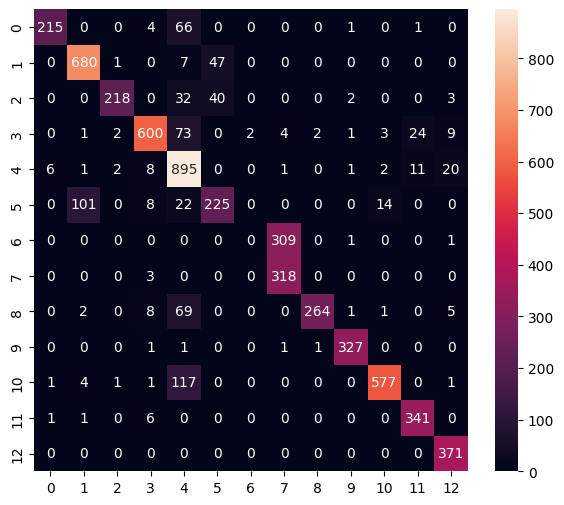

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.75      0.84       287
           1       0.86      0.93      0.89       735
           2       0.97      0.74      0.84       295
           3       0.94      0.83      0.88       721
           4       0.70      0.95      0.80       947
           5       0.72      0.61      0.66       370
           6       0.00      0.00      0.00       311
           7       0.50      0.99      0.67       321
           8       0.99      0.75      0.86       350
           9       0.98      0.99      0.98       331
          10       0.97      0.82      0.89       702
          11       0.90      0.98      0.94       349
          12       0.90      1.00      0.95       371

    accuracy                           0.83      6090
   macro avg       0.80      0.79      0.78      6090
weighted avg       0.81      0.83      0.81      6090



In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [60]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [61]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmp3z036nto\assets


INFO:tensorflow:Assets written to: C:\Users\PC\AppData\Local\Temp\tmp3z036nto\assets


Saved artifact at 'C:\Users\PC\AppData\Local\Temp\tmp3z036nto'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 13), dtype=tf.float32, name=None)
Captures:
  1586644990096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1586644988752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1586644989520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1586644975696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1586644982800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1586787434576: TensorSpec(shape=(), dtype=tf.resource, name=None)


6936

# Inference test

In [62]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [63]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [64]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [65]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [66]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[4.0645042e-05 2.4519672e-04 9.6705341e-01 1.8777288e-04 1.1778183e-02
 7.2365189e-03 6.8845644e-08 9.3454069e-08 1.7589143e-03 4.5496951e-10
 1.0617899e-05 5.2453543e-04 1.1164003e-02]
2
